<a href="https://colab.research.google.com/github/asipnana/ProjectNLP/blob/main/notebooks/04_fasttext.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Update Code buatan Adisca

In [2]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 35.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you hav

In [2]:
!pip install fasttext

  Using cached fasttext-0.9.3.tar.gz (73 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653908 sha256=1f4b3774a9ed5748c34f39a62c3b7d539e93b7532ec4259260023412dff75ae5
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [3]:
import fasttext
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)
from sklearn.metrics import classification_report

In [4]:
train_df = pd.read_csv("train (2).csv")
test_df = pd.read_csv("test (2).csv")

In [5]:
with open("fasttext_train.txt", "w", encoding="utf-8") as f:
    for _, row in train_df.iterrows():
        label = row['sentiment']
        review = row['clean_review']
        f.write(f"__label__{label} {review}\n")

In [6]:
model = fasttext.train_supervised(input="fasttext_train.txt", epoch=25, lr=1.0, wordNgrams=2, dim=100)

In [7]:
y_true = []
y_pred = []

for _, row in test_df.iterrows():
    review = row['clean_review']
    prediction = model.predict(review)
    predicted_label = prediction[0][0]
    predicted_label = predicted_label.replace("__label__", "")
    y_true.append(row['sentiment'])
    y_pred.append(predicted_label)

In [8]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy: ", accuracy)

f1 = f1_score(y_true, y_pred, average="weighted")
print("F1-Score: ", f1)

Accuracy:  0.9396984924623115
F1-Score:  0.9396396878007056


In [9]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

    Negative       0.93      0.96      0.94       413
    Positive       0.95      0.92      0.94       383

    accuracy                           0.94       796
   macro avg       0.94      0.94      0.94       796
weighted avg       0.94      0.94      0.94       796



In [10]:
results = pd.DataFrame({
    "Model": ["FastText"], "Accuracy": [accuracy_score(y_true, y_pred)],
    "Precision": [precision_score(y_true, y_pred, average="weighted")],
    "Recall": [recall_score(y_true, y_pred, average="weighted")],
    "F1": [f1_score(y_true, y_pred, average="weighted")]
})

print(results)

      Model  Accuracy  Precision    Recall       F1
0  FastText  0.939698   0.940165  0.939698  0.93964


In [11]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

y_true = []
y_pred_labels = []
y_pred_probs = []

POSITIVE_LABEL = "Positive"

for _, row in test_df.iterrows():
    review = str(row['clean_review']).strip() if pd.notna(row['clean_review']) else "kosong"

    predictions, probabilities = model.predict(review, k=2)

    top_label = predictions[0].replace("__label__", "")
    y_pred_labels.append(top_label)

    prob_dict = {pred.replace("__label__", ""): prob for pred, prob in zip(predictions, probabilities)}

    if POSITIVE_LABEL in prob_dict:
        pos_prob = prob_dict[POSITIVE_LABEL]
    else:
        other_label = list(prob_dict.keys())[0]
        pos_prob = 1.0 - prob_dict[other_label]

    y_pred_probs.append(pos_prob)
    y_true.append(row['sentiment'])

# Konversi y_true ke biner (0 dan 1) khusus untuk perhitungan ROC-AUC dan Log Loss
y_true_binary = [1 if label == POSITIVE_LABEL else 0 for label in y_true]

# --- HITUNG METRIKS ---
accuracy = accuracy_score(y_true, y_pred_labels)
precision = precision_score(y_true, y_pred_labels, pos_label=POSITIVE_LABEL)
recall = recall_score(y_true, y_pred_labels, pos_label=POSITIVE_LABEL)
f1 = f1_score(y_true, y_pred_labels, pos_label=POSITIVE_LABEL)

roc_auc = roc_auc_score(y_true_binary, y_pred_probs)
logloss = log_loss(y_true_binary, y_pred_probs)

fasttext_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Log Loss"],
    "Value": [accuracy, precision, recall, f1, roc_auc, logloss]
})

print("FastText Metrics:")
print(fasttext_results)

FastText Metrics:
      Metric     Value
0   Accuracy  0.939698
1  Precision  0.953930
2     Recall  0.919060
3         F1  0.936170
4    ROC-AUC  0.983819
5   Log Loss  0.262138


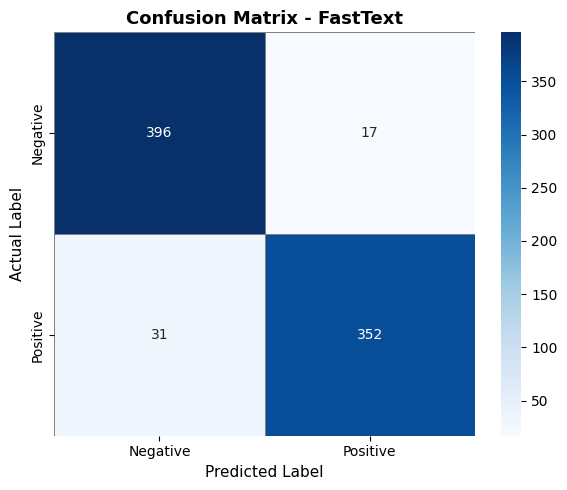

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Urutan label
labels = ["Negative", "Positive"]

# Buat confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred_labels,
    labels=labels
)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="gray"
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)
plt.title("Confusion Matrix - FastText", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [13]:
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {l}" for l in labels],
    columns=[f"Predicted {l}" for l in labels]
)

print(cm_df)

                 Predicted Negative  Predicted Positive
Actual Negative                 396                  17
Actual Positive                  31                 352


In [14]:
import os

os.makedirs("/content/ProjectNLP/models/fasttext", exist_ok=True)
model.save_model("/content/ProjectNLP/models/fasttext/fasttext_model.bin")

print("Mantap! Model FastText sudah di save.")

Mantap! Model FastText sudah di save.
